In [42]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [43]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata.h5ad')

In [44]:
len(adata[adata.obs['timepoint'] == 'F2'].obs['sample_x'].unique())

28

In [45]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

In [46]:
blood = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/blood_tcr_analysis/blood_CDR3_beta.csv')

In [47]:
blood['patient_timepoint'] = blood['patient'].astype(str) + '_' + blood['timepoint'].astype(str)

In [48]:
blood[blood['timepoint'] != 'B Beta'][[
    'totalUMICount','patient_timepoint']].groupby('patient_timepoint').sum().sort_values('totalUMICount').tail(60)

,totalUMICount
patient_timepoint,
E17_EOT,20767
E19_FU1,22085
E17_B,23076
E44_FU1,24170
E35_FU1,24174
E33_FU1,24443
E18_B,24546
E44_EOT,25403
E39_B,26983


In [49]:
blood[blood['timepoint'] != 'B Beta'][[
    'totalUMICount','patient_timepoint']].groupby('patient_timepoint').sum().sort_values('totalUMICount')

,totalUMICount
patient_timepoint,
E49_B,416
E03_B,477
E06_B,551
E45_B,775
E25_FU1,1339
...,...
E39_FU2,161718
E03_FU2,183592
E30_B,260198


Text(0.5, 1.0, 'Blood TCR UMI counts in each sample')

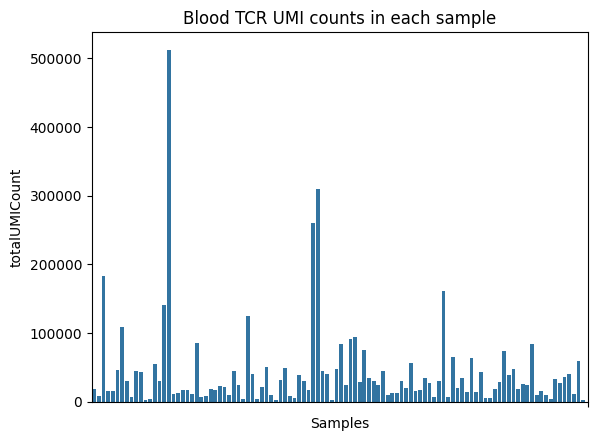

In [50]:
blood_umis = blood[(blood['timepoint'] != 'B Beta') & ~(
    blood['patient_timepoint'].isin(['E49_B', 'E06_B', 'E45_B', 'E03_B', 'E25_FU1', 'E09_FU2', 'E42_FU1'])
)][[
    'totalUMICount','patient_timepoint']].groupby('patient_timepoint').sum().sort_index()
sns.barplot(data=blood_umis,y='totalUMICount',x=blood_umis.index)
plt.xticks('')
plt.xlabel('Samples')
plt.title('Blood TCR UMI counts in each sample')

In [51]:
blood[blood['timepoint'] != 'B Beta']['patient_timepoint'].value_counts().sort_values().head(60
                                                                                            )

E49_B       165
E06_B       190
E45_B       331
E03_B       380
E25_FU1     483
E09_FU2     655
E42_FU1     771
E31_FU1    1010
E28_B      1068
E49_FU2    1238
E11_B      1252
E11_FU1    1568
E19_B      1786
E42_EOT    1899
E18_EOT    2101
E47_B      2125
E42_B      2219
E09_B      2293
E15_FU2    2537
E29_B      2544
E40_B      2550
E39_EOT    2873
E02_B      2949
E17_FU1    2994
E16_B      3453
E15_B      3743
E37_B      3748
E27_FU2    3771
E12_EOT    3892
E45_FU1    3944
E44_EOT    4201
E15_EOT    4263
E36_B      4526
E14_B      4539
E46_FU1    4636
E28_FU2    4728
E41_FU1    4911
E04_FU1    4918
E14_FU1    4919
E36_FU1    5113
E28_EOT    5184
E17_B      5262
E49_EOT    5367
E14_FU2    5375
E16_FU2    5491
E41_B      5549
E38_B      5589
E16_FU1    5683
E17_EOT    5814
E42_FU2    6008
E43_B      6173
E06_FU2    6284
E43_FU2    6398
E37_FU1    6424
E04_B      6571
E38_FU1    6587
E40_FU1    6727
E29_FU2    7075
E44_B      7243
E46_B      7257
Name: patient_timepoint, dtype: int64

Text(0.5, 1.0, 'Blood TCR Number of clonotypes in each sample')

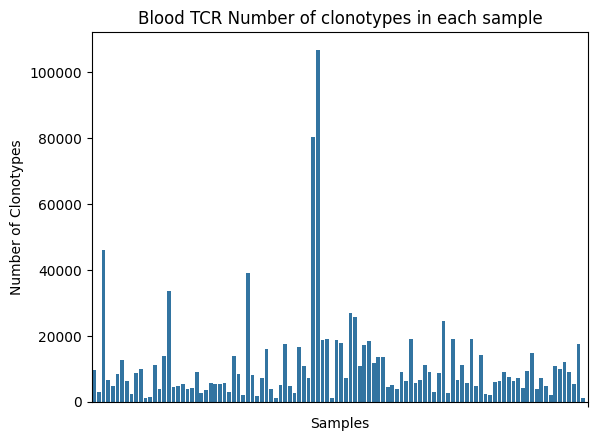

In [52]:
sns.barplot(blood[(blood['timepoint'] != 'B Beta') & ~(
    blood['patient_timepoint'].isin(['E49_B', 'E06_B', 'E45_B', 'E03_B', 'E25_FU1', 'E09_FU2', 'E42_FU1'])
)]['patient_timepoint'].value_counts().sort_index())
plt.xticks('')
plt.xlabel('Samples')
plt.ylabel('Number of Clonotypes')
plt.title('Blood TCR Number of clonotypes in each sample')